### Подготовка данных

In [82]:
import warnings
import itertools
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly_champagne_sales.csv"
time_series = pd.read_csv(url)

time_series.sample(5)

,Month,Sales
7,1964-08,2212
32,1966-09,3528
104,1972-09,5877
72,1970-01,2639
20,1965-09,3595


In [83]:
len(time_series)

105

In [84]:
time_series.isnull().sum()

,0
Month,0
Sales,0


In [85]:
time_series.dtypes

,0
Month,object
Sales,int64


In [86]:
time_series['Month'] = pd.to_datetime(time_series['Month'])
time_series.set_index('Month', inplace=True)

In [87]:
time_series.dtypes

,0
Sales,int64


In [88]:
time_series.sample(5)

,Sales
Month,
1972-07-01,4298
1968-10-01,6922
1967-07-01,3663
1965-05-01,3776
1969-10-01,6872


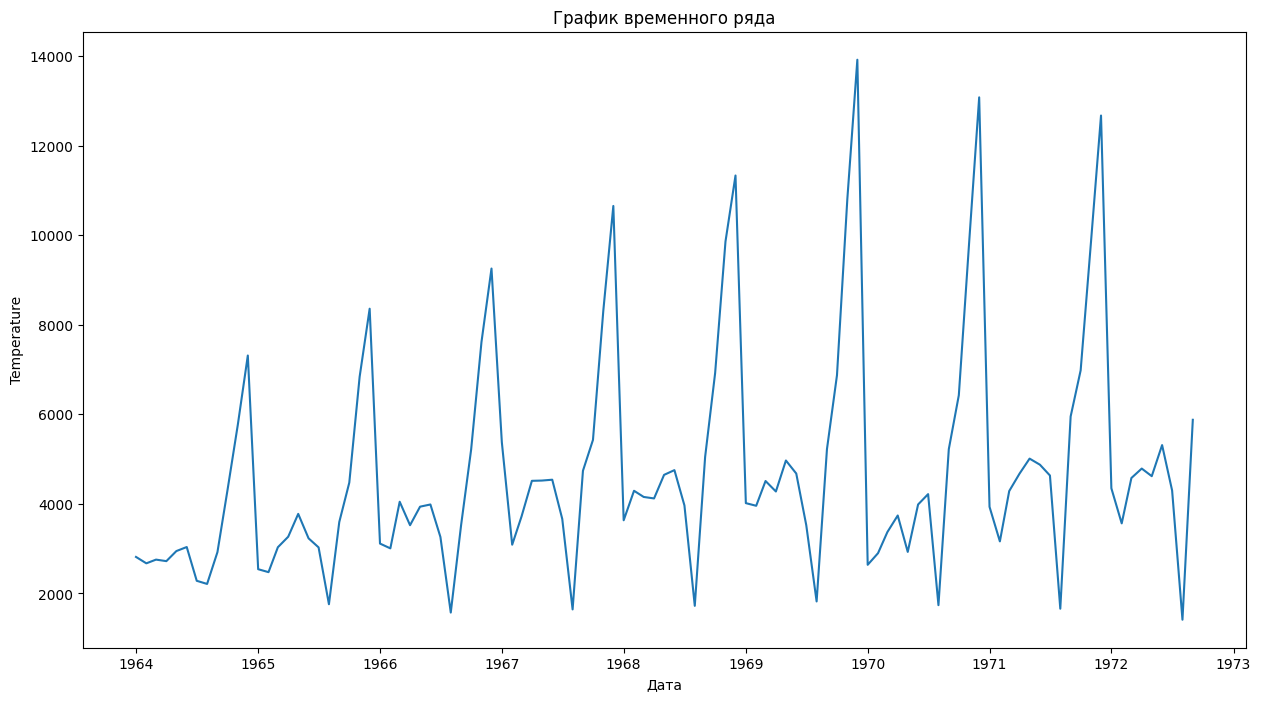

In [89]:
plt.figure(figsize=(15,8))
plt.plot(time_series['Sales'])
plt.title('График временного ряда')
plt.xlabel('Дата')
plt.ylabel('Temperature')
plt.show()

In [90]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings("ignore")

In [91]:
train, test = train_test_split(time_series, test_size=0.2, shuffle=False)

In [92]:
train.shape

(84, 1)

In [93]:
test.shape

(21, 1)

In [94]:
test.head()

,Sales
Month,
1971-01-01,3934
1971-02-01,3162
1971-03-01,4286
1971-04-01,4676
1971-05-01,5010


### Поиск параметров

In [95]:
def search_optimal_arima(time_series, seasonal_cycle):
    # Взял максимальный интервал, которое мое устройство осилило
    order_vals = diff_vals = ma_vals = range(0, 10)
    pdq_combinations = list(itertools.product(order_vals, diff_vals, ma_vals))

    smallest_aic = float("inf")
    optimal_order_param = None

    for order_param in pdq_combinations:
        try:
            arima_model = ARIMA(time_series,
                                order=order_param,
                                enforce_stationarity=False,
                                enforce_invertibility=False)

            model_results = arima_model.fit()
            if model_results.aic < smallest_aic:
                smallest_aic = model_results.aic
                optimal_order_param = order_param
        except:
            print("Aaa")
            continue

    return optimal_order_param, smallest_aic

seasonal_cycle_length = 12
#optimal_order_param, smallest_aic = search_optimal_arima(train, seasonal_cycle_length)
optimal_order_param, smallest_aic = (9, 5, 9), 1259.7005665206184
print('ARIMA{} - AIC:{}'.format(optimal_order_param, smallest_aic))

ARIMA(9, 5, 9) - AIC:1259.7005665206184


### Обучение модели

In [96]:
from statsmodels.tsa.arima.model import ARIMA

order = optimal_order_param

model = ARIMA(train, order=order)

In [97]:
fitted_model = model.fit()
fitted_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Sales   No. Observations:                   84
Model:                 ARIMA(9, 5, 9)   Log Likelihood                -734.387
Date:                Tue, 28 Apr 2026   AIC                           1506.775
Time:                        17:05:50   BIC                           1551.794
Sample:                    01-01-1964   HQIC                          1524.811
                         - 12-01-1970                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.9821      0.240     -8.267      0.000      -2.452      -1.512
ar.L2         -3.0460      0.408     -7.462      0.000      -3.846      -2.246
ar.L3         -3.9938      0.639     -6.251      0.000      -5.246      -2.741
ar.L4         -4.5657      0.746     -6.124      0.000      -6.027      -3.104
ar.L5         -4.5201      0.796     -5.677      0.000      -6.081      -2.960
ar.L6         -3.5827      0.740     -4.844      0.000      -5.032      -2.133
ar.L7         -2.6387      0.582     -4.536      0.000      -3.779      -1.499
ar.L8         -1.5476      0.356     -4.348      0.000      -2.245      -0.850
ar.L9         -0.5749      0.187     -3.081      0.002      -0.941      -0.209
ma.L1         -1.6663      1.670     -0.998      0.318      -4.940       1.607
ma.L2          1.1768      4.706      0.250      0.803      -8.046      10.400
ma.L3         -0.2938      6.094     -0.048      0.962     -12.237      11.650
ma.L4         -0.2137      5.853     -0.037      0.971     -11.686      11.259
ma.L5         -0.1890      5.823     -0.032      0.974     -11.601      11.223
ma.L6         -0.3239      5.925     -0.055      0.956     -11.937      11.289
ma.L7          1.2441      4.321      0.288      0.773      -7.226       9.714
ma.L8         -1.6199      1.443     -1.123      0.262      -4.448       1.208
ma.L9          0.9125      0.218      4.191      0.000       0.486       1.339
sigma2      3.379e+06   4.18e-05   8.09e+10      0.000    3.38e+06    3.38e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.46   Jarque-Bera (JB):                49.02
Prob(Q):                              0.23   Prob(JB):                         0.00
Heteroskedasticity (H):               2.36   Skew:                            -1.27
Prob(H) (two-sided):                  0.03   Kurtosis:                         5.90
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 2.83e+28. Standard errors may be unstable.
"""

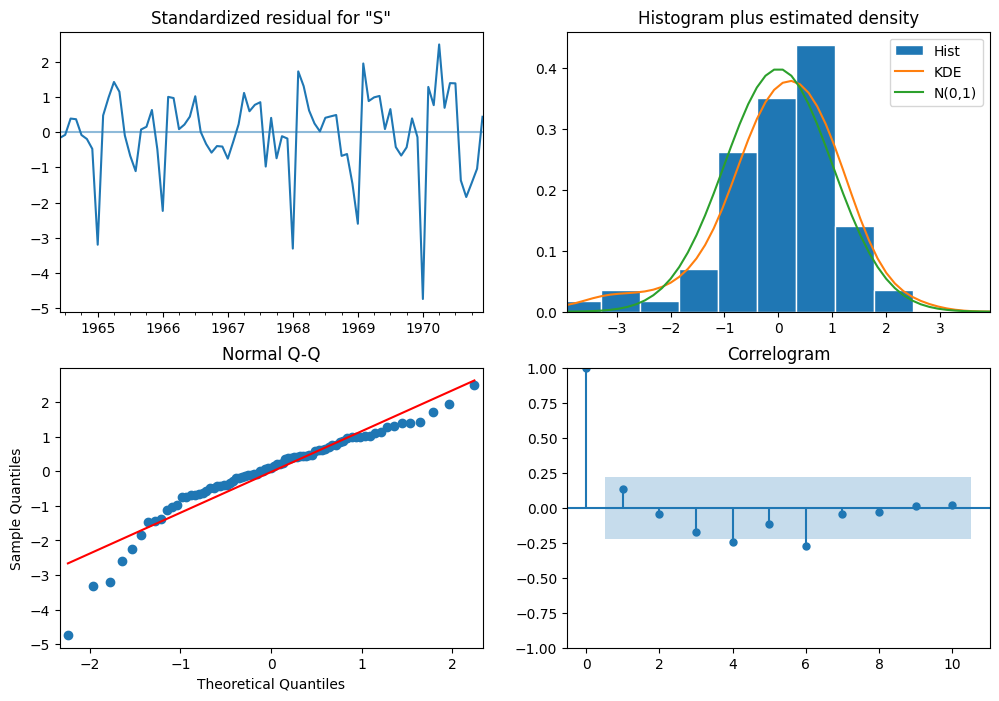

In [98]:
fitted_model.plot_diagnostics(figsize=(12, 8))
plt.show()

### Прогноз

In [99]:
pred = fitted_model.get_prediction(start=test.index[0], end=test.index[-1], dynamic=False)
forecast_values = pred.predicted_mean

In [100]:
actual_values = test
forecast_mse = ((forecast_values - actual_values) ** 2).mean()

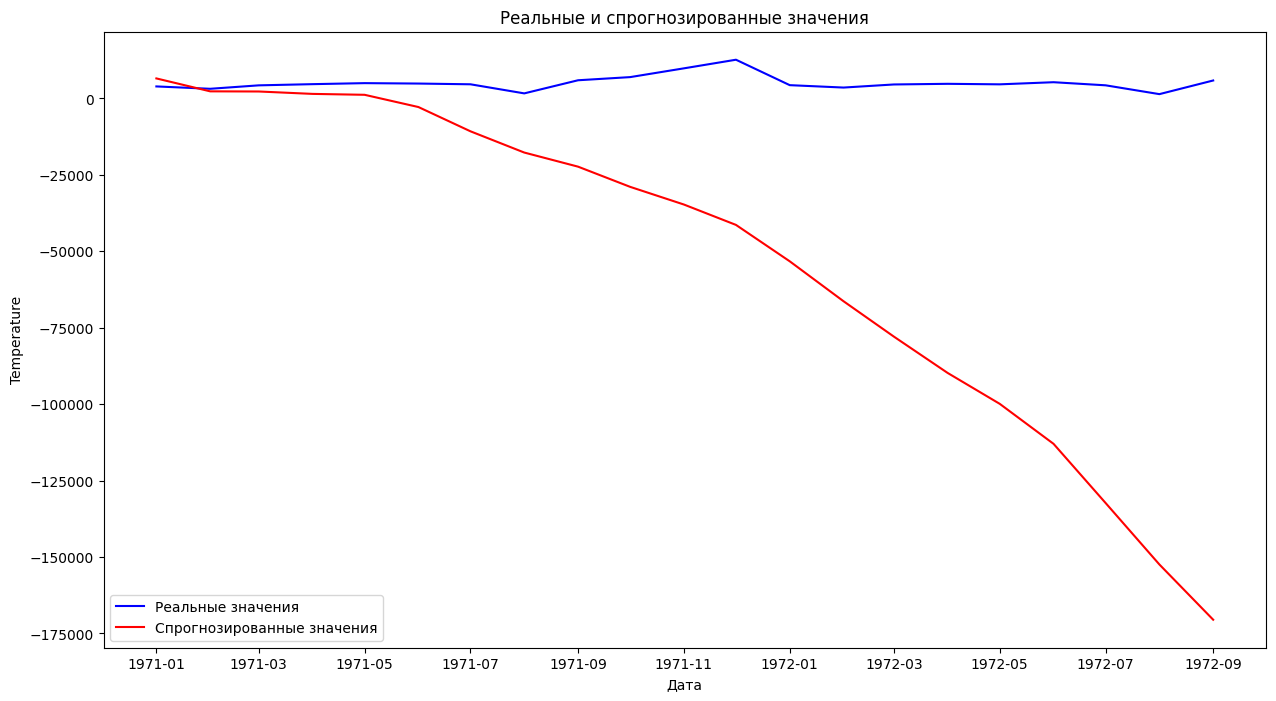

In [101]:
plt.figure(figsize=(15,8))

plt.plot(actual_values.index, actual_values, label='Реальные значения', color='blue')

plt.plot(forecast_values.index, forecast_values, label='Спрогнозированные значения', color='red')

plt.title('Реальные и cпрогнозированные значения')
plt.xlabel('Дата')
plt.ylabel('Temperature')
plt.legend()

plt.show()

### Реализации бутстрапа

In [102]:
def residual_bootstrap(fitted_model, steps, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = np.random.choice(residuals, size=steps, replace=True)
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [103]:
# max - половина максимальной ошибки
# mean - половина средней ошибки
# median - половина медианной ошибки
def naive_bootstraps(fitted_model, steps, method, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    abs_resids = np.abs(residuals)

    if method == 'max':
        error_magnitude = np.max(abs_resids) / 2.0
    elif method == 'mean':
        error_magnitude = np.mean(abs_resids) / 2.0
    elif method == 'median':
        error_magnitude = np.median(abs_resids) / 2.0
    else:
        raise ValueError("[naive] no such method ")

    forecasts = []

    for _ in range(n_bootstrap):
        boot_resid = error_magnitude
        # Симуляция будущих значений с учётом структуры модели
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',          # начать с конца обучающей выборки
            repetitions=1,
            random_errors=boot_resid.reshape(-1,1)  # передаём бутстреп-остатки
        )

        sim_values = np.asarray(sim).flatten()
        # Если нужно добавить внешний тренд/сезонность – убедитесь, что модель их не содержит
        # В противном случае не применяйте add_trend_and_seasonal повторно.
        boot_forecast = sim_values
        forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [104]:
!pip install arch

import arch
from arch.bootstrap import MovingBlockBootstrap

def arch_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000):
    residuals = fitted_model.resid.values
    point_forecast = fitted_model.forecast(steps=steps)

    mbb = MovingBlockBootstrap(block_length, residuals)
    forecasts = []

    for data in mbb.bootstrap(n_bootstrap):
        # data[0][0] содержит сгенерированный ряд остатков
        boot_resid = data[0][0]

        if len(boot_resid) >= steps:
            boot_forecast = point_forecast.values + boot_resid[:steps]
            forecasts.append(boot_forecast)
        else:
            # Если остатков не хватает, повторяем их циклически
            repeated_resid = np.tile(boot_resid, int(np.ceil(steps / len(boot_resid))))[:steps]
            boot_forecast = point_forecast.values + repeated_resid
            forecasts.append(boot_forecast)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)

    return lower, upper, forecasts

In [105]:
!pip install tsbootstrap

from tsbootstrap import WholeSieveBootstrap

def sieve_bootstrap(fitted_model, steps, min_lag=1, max_lag=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    sieve = WholeSieveBootstrap(n_bootstraps=n_bootstrap)

    boot_residuals = sieve.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

In [106]:
from tsbootstrap import MovingBlockBootstrap as tsbootstrap_mbb

def tsbootstrap_block_bootstrap(fitted_model, steps, block_length=12, n_bootstrap=1000, random_state=42):
    residuals = fitted_model.resid.values

    centered_resid = residuals - np.mean(residuals)

    mbb = tsbootstrap_mbb(n_bootstraps=n_bootstrap, rng=random_state, block_length=block_length)

    boot_residuals = mbb.bootstrap(centered_resid)

    boot_residuals_list = []
    for _ in range(n_bootstrap):
        boot_residuals_list.append(next(boot_residuals))
    boot_residuals = np.array(boot_residuals_list)

    forecasts = []
    for i in range(n_bootstrap):
        boot_resid = boot_residuals[i, :]
        sim = fitted_model.simulate(
            nsimulations=steps,
            anchor='end',
            repetitions=1,
            random_errors=boot_resid.reshape(-1, 1)
        )
        sim_values = np.asarray(sim).flatten()
        forecasts.append(sim_values)

    forecasts = np.array(forecasts)
    lower = np.percentile(forecasts, 2.5, axis=0)
    upper = np.percentile(forecasts, 97.5, axis=0)
    return lower, upper, forecasts

### Сравнение методов

In [107]:
def evaluate(true_values, lower, upper):
    true_vals = np.array(true_values).flatten()

    # доля истинных значений, попавших в интервал
    coverage = np.mean((lower <= true_vals[:len(lower)]) & (true_vals[:len(lower)] <= upper))

    # средняя ширина интервала
    avg_width = np.mean(upper - lower)
    return coverage, avg_width

forecast_steps = 20
forecast = fitted_model.forecast(steps=forecast_steps)

test_values = test.values.flatten()[:forecast_steps]

results = {}

# ARIMA
try:
    prediction = fitted_model.get_forecast(forecast_steps)
    arima_forecast = prediction.predicted_mean
    arima_ci = prediction.conf_int(alpha=0.05)
    lower_arima = arima_ci.iloc[:, 0]
    upper_arima = arima_ci.iloc[:, 1]
    coverage_arima, width_arima = evaluate(test_values, lower_arima, upper_arima)
    results['ARIMA'] = {'coverage': coverage_arima, 'width': width_arima, 'lower': lower_arima, 'upper': upper_arima}
    print("ARIMA - OK")
except Exception as e:
    print(f"Arima error: {e}")

# Residual Bootstrap
try:
    lower_res_c, upper_res_c, all_forecasts_res_c  = residual_bootstrap(fitted_model, forecast_steps)
    coverage_res_c, width_res_c = evaluate(test_values, lower_res_c, upper_res_c)
    results['Residual Bootstrap Correct'] = {'coverage': coverage_res_c, 'width': width_res_c, 'lower': lower_res_c, 'upper': upper_res_c}
    print("Residual Bootstrap Correct - OK")
except Exception as e:
    print(f"Residual Bootstrap Correct error: {e}")

# Naive
try:
    for method in ["max", "mean", "median"]:
        lower_naive, upper_naive, all_forecasts_naive  = naive_bootstraps(fitted_model, forecast_steps, method)
        coverage_naive, width_naive = evaluate(test_values, lower_naive, upper_naive)
        results['Naive-' + method] = {'coverage': coverage_naive, 'width': width_naive, 'lower': lower_naive, 'upper': upper_naive}
        print(f" ### Naive {method} - OK")
    print("Naive - OK")
except Exception as e:
    print(f"Naive: {e}")

# ARCH block Bootstrap
try:
    lower_arch, upper_arch, _ = arch_block_bootstrap(fitted_model, forecast_steps, block_length=12)
    coverage_arch, width_arch = evaluate(test_values, lower_arch, upper_arch)
    results['ARCH Block Bootstrap'] = {'coverage': coverage_arch, 'width': width_arch, 'lower': lower_arch, 'upper': upper_arch}
    print("ARCH Block Bootstrap - OK")
except Exception as e:
    print(f"ARCH Block Bootstrap error: {e}")

# Sieve bootstrap
try:
    lower_sieve, upper_sieve, _ = sieve_bootstrap(fitted_model, forecast_steps)
    coverage_sieve, width_sieve = evaluate(test_values, lower_sieve, upper_sieve)
    results['Sieve Bootstrap'] = {'coverage': coverage_sieve, 'width': width_sieve, 'lower': lower_sieve, 'upper': upper_sieve}
    print("Sieve Bootstrap - OK")
except Exception as e:
    print(f"Sieve Bootstrap error: {e}")

# tsbootstrap block bootstrap
try:
    lower_block, upper_block, _ = tsbootstrap_block_bootstrap(fitted_model, forecast_steps)
    coverage_block, width_block = evaluate(test_values, lower_block, upper_block)
    results['Tsbootstrap Block Bootstrap'] = {'coverage': coverage_block, 'width': width_block, 'lower': lower_block, 'upper': upper_block}
    print("Tsbootstrap Block Bootstrap - OK")
except Exception as e:
    print(f"Tsbootstrap Block Bootstrap error: {e}")

results_df = pd.DataFrame(results).T[['coverage', 'width']]
print("\n" + "="*50)
print("РЕЗУЛЬТАТЫ СРАВНЕНИЯ:")
print("="*50)
print(results_df)

ARIMA - OK
Residual Bootstrap Correct - OK
 ### Naive max - OK
 ### Naive mean - OK
 ### Naive median - OK
Naive - OK
ARCH Block Bootstrap - OK
[ 2832.76917313 -9248.63008536  5055.99209637  1566.91781535
  1820.39570167 -1063.89515611  -403.29356455  1981.47557186
  1747.70085891  -286.19073618  -616.38320408 -1414.84221352
 -9117.41757857  1264.6821182   2505.58916304  3505.28238954
  2797.5789796   -200.05010843 -1559.22547259 -2478.45932204
   183.35285458   352.22792407  1388.11081868 -1032.94687173
 -4806.07569679  2166.25019975  2079.03590604   195.83363656
   467.3919609    933.32069507  2125.46440166    34.83797861
  -669.80047882 -1165.59505502  -779.86300315  -802.95627418
 -1489.02792983  -532.08945369   468.68955063  2226.80099094
  1192.16779951  1549.51048338  1689.84287356 -1899.89096367
   811.77704403 -1433.47201023  -206.56824247  -336.05305642
 -6395.03996075  3360.51801839  2539.63339319  1203.67474558
   490.96448161    58.03721295   800.90183177   878.22351069
  

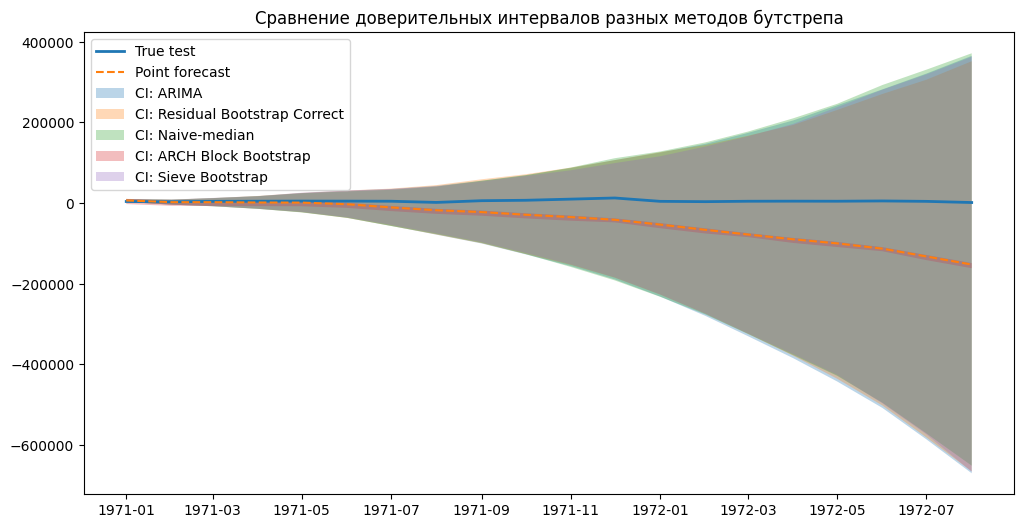

In [108]:
plt.figure(figsize=(12,6))
plt.plot(test.index[:forecast_steps], test_values, label='True test', linewidth=2)
plt.plot(test.index[:forecast_steps], forecast[:forecast_steps], label='Point forecast', linestyle='--')

to_plot = ['ARIMA', 'Residual Bootstrap Correct', 'Naive-median', 'ARCH Block Bootstrap', 'Sieve Bootstrap']

for name in results.keys():
    if name not in to_plot:
        continue

    lower = results[name]['lower']
    upper = results[name]['upper']

    plt.fill_between(test.index[:forecast_steps], lower, upper, alpha=0.3, label=f'CI: {name}')

plt.legend()
plt.title('Сравнение доверительных интервалов разных методов бутстрепа')
plt.show()